## HW 3: Q-learning
_Reference: based on Practical RL course by YSDA_

In this notebook you have to master Q-learning and apply it to RL problems once again.

To get used to `gymnasium` package, please, refer to the [documentation](https://gymnasium.farama.org/introduction/basic_usage/).


In the end of the notebook, please, copy the functions you have implemented to the template file and submit it to the Contest.

In [2]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

## Step 1: Tabular Q-learning with SoftMax policy

We want you to implement Q-learning algorithm with softmax policy.

You need to implement QLearningAgent (follow instructions for each method) and use it on a number of tests below.

SoftMax policy means that actions probabilities are computed from q-values using softmax function, where $\tau$ is the softmax temperature:

$$ \pi(a_i \mid s) = \operatorname{softmax} \left( \left\{ {Q(s, a_j) \over \tau} \right\}_{j=1}^n \right)_i = {\operatorname{exp} \left( Q(s,a_i) / \tau \right)  \over {\sum_{j}  \operatorname{exp} \left( Q(s,a_j) / \tau  \right)}} $$

### Температура в softmax?

- Низкая температура → жадный агент (эксплуатация).
    - Разница между вероятностями стирается.
    - Растёт рандомизация выбора.

- Высокая температура → разведка (exploration).
    - Вероятность "лучшего" действия ↑
    - Остальные действия почти зануляются.

First, implement softmax. Do not forget that exponent of large value might be too big to fit in float. Substract maximum for numerical stability.

In [3]:
def my_softmax(values: np.ndarray, T=1.):
    if np.isclose(T, 0.0):
        raise ValueError("T is too close to 0.0")
    
    values = values / T 
    values_normalized = values - np.max(values)
    exp_values = np.exp(values_normalized)
    probas = exp_values  / np.sum(exp_values)
    assert probas is not None
    return probas

Now check your Softmax using the following tests.

In [4]:
import torch
test_data = np.arange(5)
for temp in [0.1, 0.5, 1, 5]:
  local_softmax = my_softmax(test_data, T=temp)
  with torch.no_grad():
    torch_softmax = torch.softmax(torch.from_numpy(test_data)/temp, dim=-1)
  assert np.allclose(local_softmax, torch_softmax.numpy())
  print(f'Passed for temp={temp}')

Passed for temp=0.1
Passed for temp=0.5
Passed for temp=1
Passed for temp=5


Simple visualization for your convenience

Text(0.5, 1.0, 'Example softmax with temp = 1')

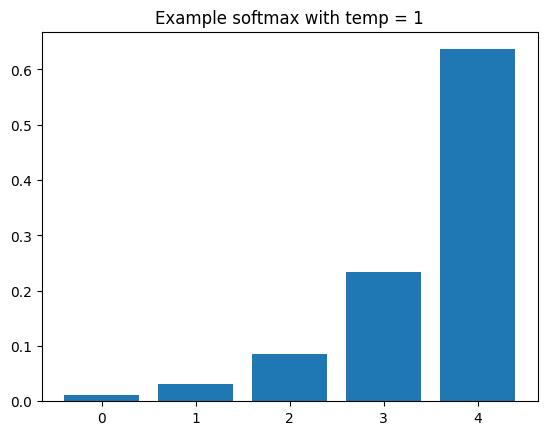

In [5]:
temp = 1
plt.bar(test_data, my_softmax(test_data, T=temp))
plt.title(f'Example softmax with temp = {temp}')

Now implement the `QLearningAgent`. You will solve several environments using it and later submit to the Contest.

In [ ]:
import random
from collections import defaultdict


class QLearningAgent:
    def __init__(self, alpha, discount, get_legal_actions, temp=1.0, eps_start=None, eps_end=None, n_steps=None):
        """
        Q-Learning Agent
        based on https://inst.eecs.berkeley.edu/~cs188/sp19/projects.html
        Instance variables you have access to
          - self.alpha (learning rate)
          - self.discount (discount rate aka gamma)
          - self.temp (softmax temperature)

        Functions you should use
          - self.get_legal_actions(state) {state, hashable -> list of actions, each is hashable}
            which returns legal actions for a state
          - self.get_qvalue(state,action)
            which returns Q(state,action)
          - self.set_qvalue(state,action,value)
            which sets Q(state,action) := value
        !!!Important!!!
        Note: please avoid using self._qValues directly.
            There's a special self.get_qvalue/set_qvalue for that.
        """

        self.get_legal_actions = get_legal_actions
        self._qvalues = defaultdict(lambda: defaultdict(lambda: 0))
        self.alpha = alpha
        self.discount = discount
        self.temp = temp
        
        # epsilon parameters
        self.eps_start = eps_start
        self.eps_end = eps_end
        self.n_steps = n_steps
        if eps_start is not None and eps_end is not None and n_steps is not None:
            # вычисляем коэффициент затухания, чтобы eps_start → eps_end за n_steps
            self.eps = eps_start
            self.eps_decay = (eps_end / eps_start) ** (1.0 / n_steps)
        else:
            self.eps = eps_start
            self.eps_decay = None

    def decay_eps(self):
        """Обновляем epsilon каждый шаг, если настроено затухание"""
        if self.eps_decay is None:
            raise Exception("Provide eps parameters to agent constructor")
        
        self.eps = max(self.eps * self.eps_decay, self.eps_end)
            
    def get_qvalue(self, state, action):
        """Returns Q(state,action)"""
        return self._qvalues[state][action]

    def set_qvalue(self, state, action, value):
        """Sets the Qvalue for [state,action] to the given value"""
        self._qvalues[state][action] = value

    def get_value(self, state):
        """
        Compute your agent's estimate of V(s) using current q-values
        V(s) = max_over_action Q(state,action) over possible actions.
        Note: please take into account that q-values can be negative.
        """
        possible_actions = self.get_legal_actions(state)

        if len(possible_actions) == 0:
            return 0.0

        qvalues = [self.get_qvalue(state=state, action=a) for a in possible_actions]

        value = max(qvalues) 

        return value

    def update(self, state, action, reward, next_state):
        """
        You should do your Q-Value update here:
           Q(s,a) := (1 - alpha) * Q(s,a) + alpha * (r + gamma * V(s'))
        """

        # agent parameters
        gamma = self.discount
        lr = self.alpha

        qvalue = self.get_qvalue(state=state, action=action)
        value_new = self.get_value(state=next_state)
        
        qvalue_new = (1 - lr) * qvalue + lr * (reward + gamma * value_new)

        self.set_qvalue(state, action, qvalue_new)

    def get_best_action(self, state):
        """
        Compute the best action to take in a state (using current q-values).
        """
        possible_actions = self.get_legal_actions(state)

        if len(possible_actions) == 0:
            return None

        qvalues = [self.get_qvalue(state=state, action=a) for a in possible_actions]

        best_action = possible_actions[np.argmax(qvalues)]

        return best_action

    def get_softmax_policy(self, state):
        """
        Compute all actions probabilities in the current state according
        to their q-values using softmax policy.

        p(a_i|s) = softmax([q(s, a_1), q(s, a_2), ... q(s, a_k)])_i

        Returns:
            probabilities: np.ndarray (1, <possible actions length>)
        """
        possible_actions = self.get_legal_actions(state)
        
        if len(possible_actions) == 0:
            return None

        qvalues = np.array([self.get_qvalue(state=state, action=a) for a in possible_actions])

        probabilities = my_softmax(values=qvalues, T=self.temp)

        return probabilities


    def get_action(self, state):
        """
        Compute the action to take in the current state, including exploration.
        Select actions according to softmax policy.
        """
        possible_actions = self.get_legal_actions(state)
        
        if len(possible_actions) == 0:
            return None

        if self.eps is not None and np.random.rand() < self.eps:
            # случайное действие
            chosen_action = np.random.choice(possible_actions)
        else:
            # выбираем по softmax
            probabilities = self.get_softmax_policy(state=state)
            chosen_action = np.random.choice(possible_actions, p=probabilities)

        return chosen_action

### Try it on taxi

Here we use the Q-Learning agent on the Taxi-v3 environment from OpenAI gym.
You will need to complete a few of its functions.

In [7]:
import gymnasium as gym

env = gym.make("Taxi-v3", render_mode="rgb_array")

n_actions = env.action_space.n

/home/ars/Projects/yandex-ml/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


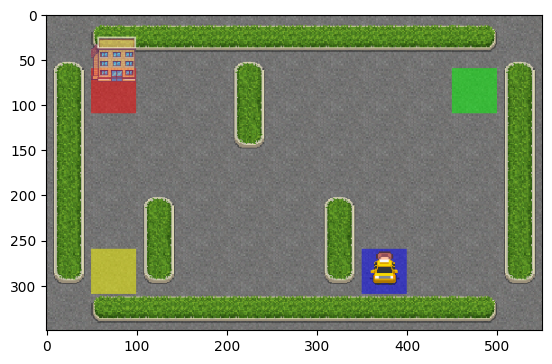

In [8]:
s, _ = env.reset()
plt.imshow(env.render())

In [9]:
agent = QLearningAgent(alpha=0.5, discount=0.99, get_legal_actions=lambda s: range(n_actions))

In [10]:
def play_and_train(env, agent, t_max=10**4):
    """
    This function should
    - run a full game, actions given by agent's e-greedy policy
    - train agent using agent.update(...) whenever it is possible
    - return total reward
    """
    total_reward = 0.0
    s, _ = env.reset()

    for t in range(t_max):
        # get agent to pick action given state s.
        a = agent.get_action(s)

        next_s, r, done, _, _ = env.step(a)

        # train (update) agent for state s
        agent.update(s, a, r, next_s)

        s = next_s
        total_reward += r
        if done:
            break

    return total_reward

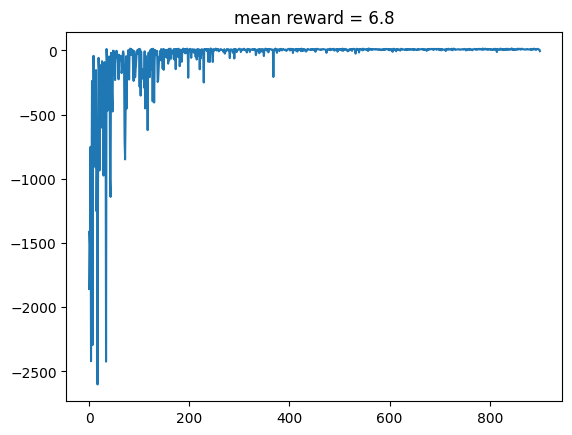

In [11]:
from IPython.display import clear_output

rewards = []
for i in range(1000):
    rewards.append(play_and_train(env, agent))

    if i % 100 == 0:
        clear_output(True)
        plt.title("mean reward = {:.1f}".format(np.mean(rewards[-10:])))
        plt.plot(rewards)
        plt.show()

# Step 2: Discretized state spaces.

Let's try solving the same `CartPole-v1` problem using Tabular Q-learning.

This environment has a continuous set of possible states, so we will have to group them into bins somehow.

Simple binarization is already present. You can play with to see what happens.

The simplest way is to use `round(x, n_digits)` (or `np.round`) to round a real number to a given amount of digits. The tricky part is to get the `n_digits` right for each state to train effectively.

Note that you don't need to convert state to integers, but to __tuples__ of any kind of values.

first state: [ 0.04902125  0.03721922 -0.02423825  0.02171677]


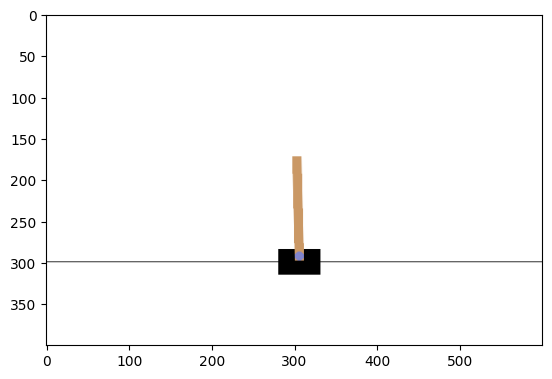

In [12]:
def make_env():
    return gym.make("CartPole-v1", render_mode="rgb_array")


env = make_env()
n_actions = env.action_space.n

print("first state: %s" % (env.reset()[0]))
plt.imshow(env.render())

### Play a few games

We need to estimate observation distributions. To do so, we'll play a few games and record all states.

In [13]:
def visualize_cartpole_observation_distribution(seen_observations):
    seen_observations = np.array(seen_observations)

    # The meaning of the observations is documented in
    # https://github.com/openai/gym/blob/master/gym/envs/classic_control/cartpole.py

    f, axarr = plt.subplots(2, 2, figsize=(16, 9), sharey=True)
    for i, title in enumerate(["Cart Position", "Cart Velocity", "Pole Angle", "Pole Velocity At Tip"]):
        ax = axarr[i // 2, i % 2]
        ax.hist(seen_observations[:, i], bins=20)
        ax.set_title(title)
        xmin, xmax = ax.get_xlim()
        ax.set_xlim(min(xmin, -xmax), max(-xmin, xmax))
        ax.grid()
    f.tight_layout()

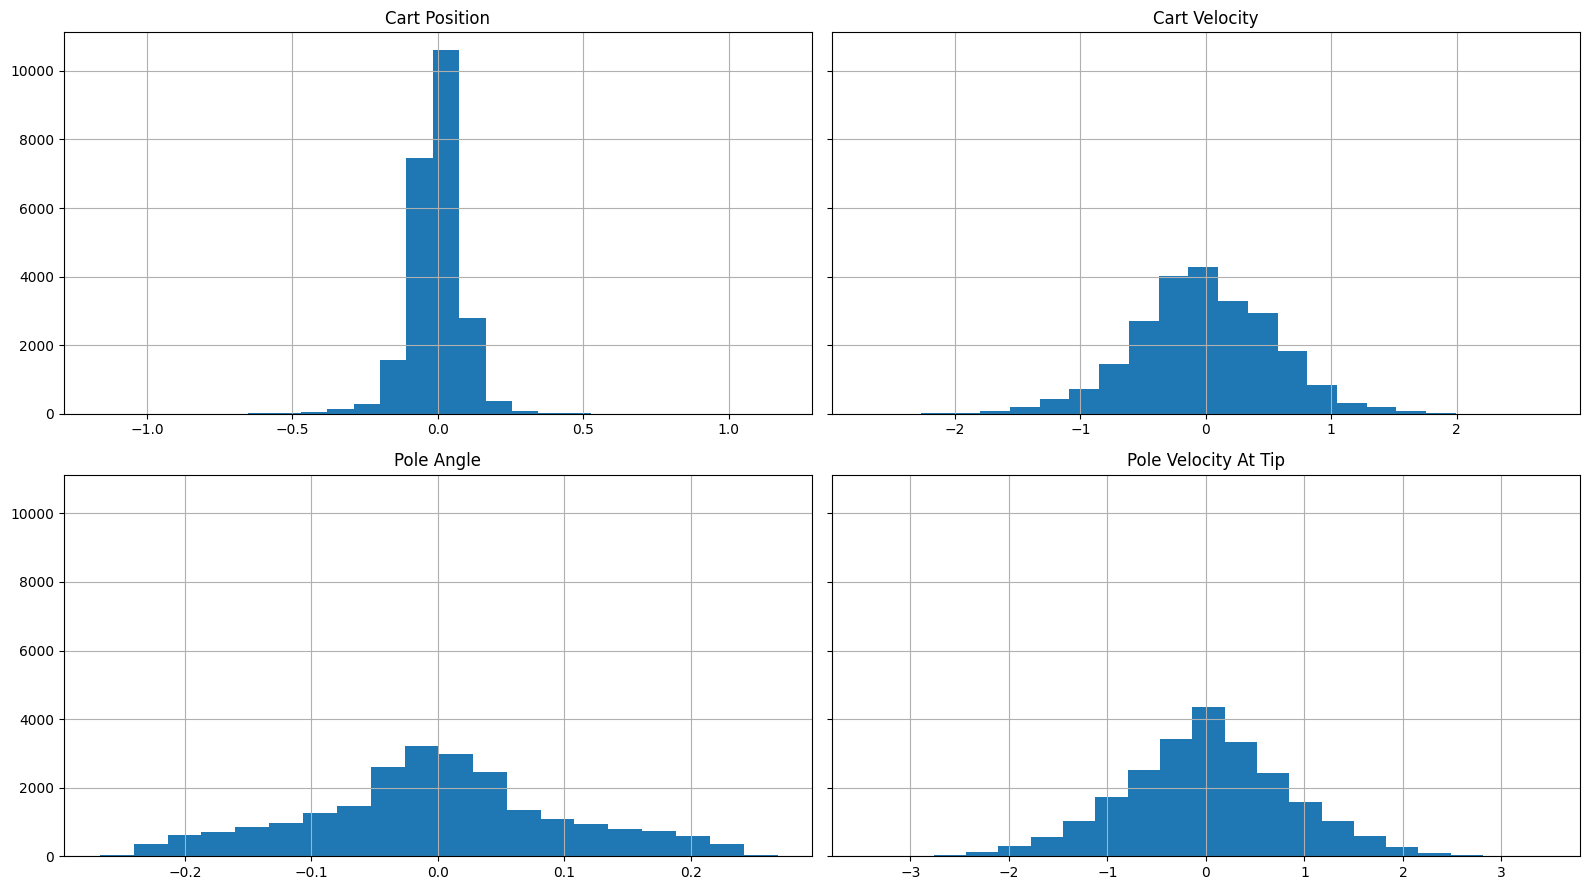

In [14]:
seen_observations = []
for _ in range(1000):
    s, _ = env.reset()
    seen_observations.append(s)
    done = False
    while not done:
        s, r, done, _, _ = env.step(env.action_space.sample())
        seen_observations.append(s)

visualize_cartpole_observation_distribution(seen_observations)

## Discretize environment

In [15]:
from gymnasium.core import ObservationWrapper

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from gymnasium.core import ObservationWrapper

# ---------- Helpers ----------
def _safe_sample_states(env, sample_size=2000):
    """Collect some states by random policy to estimate distributions / bounds."""
    samples = []
    obs = env.reset()[0]
    for _ in range(sample_size):
        samples.append(obs)
        a = env.action_space.sample()
        obs, _, done, _, _ = env.step(a)
        if done:
            obs = env.reset()[0]
    return np.array(samples)

# ---------- Discretizers ----------
class RoundDiscretizer(ObservationWrapper):
    def __init__(self, env, ndigits=(1,1,1,1)):
        super().__init__(env)
        self.ndigits = tuple(ndigits)
    def observation(self, state):
        return tuple(round(float(state[i]), self.ndigits[i]) for i in range(len(state)))

class BinDiscretizer(ObservationWrapper):
    """
    Uniform bins but guarded:
      - If observation_space has +/- inf, estimate finite low/high from samples
      - Avoid division by zero
      - Clip ratios to [0,1] and map to bins [0..n_bins-1]
    """
    def __init__(self, env, n_bins=10, low=None, high=None, sample_size=2000):
        super().__init__(env)
        self.n_bins = int(n_bins)

        # base low/high from args or observation_space
        space_low = np.array(low) if low is not None else np.array(self.observation_space.low, dtype=float)
        space_high = np.array(high) if high is not None else np.array(self.observation_space.high, dtype=float)

        # if any bounds are infinite or weird, estimate from sampling
        if not np.all(np.isfinite(space_low)) or not np.all(np.isfinite(space_high)):
            samples = _safe_sample_states(env, sample_size=sample_size)
            # per-dimension empirical bounds using percentiles to avoid outliers
            emp_low = np.quantile(samples, 0.01, axis=0)
            emp_high = np.quantile(samples, 0.99, axis=0)
            # fallback to default cardinals for CartPole-ish shapes if still degenerate
            default_low = np.array([-4.8, -3.0, -0.418, -3.0])
            default_high = np.array([4.8, 3.0, 0.418, 3.0])
            # choose finite bound per-dim
            fin_low = np.where(np.isfinite(space_low), space_low, emp_low)
            fin_high = np.where(np.isfinite(space_high), space_high, emp_high)
            # if still non-finite or degenerate, use default
            fin_low = np.where(np.isfinite(fin_low), fin_low, default_low)
            fin_high = np.where(np.isfinite(fin_high), fin_high, default_high)
            # ensure small margin
            margin = 1e-6 * (np.abs(fin_high) + 1.0)
            fin_low = fin_low - margin
            fin_high = fin_high + margin
            self.low = fin_low.astype(float)
            self.high = fin_high.astype(float)
        else:
            self.low = space_low.astype(float)
            self.high = space_high.astype(float)

        # avoid exact equal low/high -> expand tiny bit
        same_mask = (self.high - self.low) == 0
        if np.any(same_mask):
            eps = 1e-6
            self.low[same_mask] -= eps
            self.high[same_mask] += eps

    def observation(self, state):
        state = np.array(state, dtype=float)
        # clip to finite bounds
        state = np.clip(state, self.low, self.high)
        denom = (self.high - self.low)
        # avoid division by zero
        denom_safe = np.where(np.abs(denom) < 1e-12, 1.0, denom)
        ratios = (state - self.low) / denom_safe
        ratios = np.clip(ratios, 0.0, 1.0)
        discretized = np.floor(ratios * self.n_bins).astype(int)
        # map upper edge to n_bins-1
        discretized = np.clip(discretized, 0, self.n_bins - 1)
        return tuple(discretized)

class QuantileDiscretizer(ObservationWrapper):
    """
    Quantile-based discretizer. Build edges from sampled states.
    Make sure edges are strictly increasing (merge near-duplicates).
    """
    def __init__(self, env, n_bins=10, sample_size=5000):
        super().__init__(env)
        self.n_bins = int(n_bins)
        samples = _safe_sample_states(env, sample_size=sample_size)
        # compute raw edges (n_bins+1 endpoints)
        raw_edges = [np.quantile(samples[:, i], np.linspace(0, 1, self.n_bins + 1)) for i in range(samples.shape[1])]
        # ensure monotonic strictly increasing for digitize: if duplicates -> jitter small eps
        edges = []
        for e in raw_edges:
            # e[0] ... e[-1] are endpoints; we will keep full edge array, but ensure strict increase
            e = np.array(e, dtype=float)
            # replace NaN/inf with empirical min/max
            if not np.all(np.isfinite(e)):
                finite = e[np.isfinite(e)]
                if len(finite) == 0:
                    finite = np.array([-1.0, 1.0])
                e[~np.isfinite(e)] = np.min(finite) if np.isnan(e[~np.isfinite(e)]).any() else np.max(finite)
            # compact duplicates: add tiny increasing eps where necessary
            for k in range(1, len(e)):
                if e[k] <= e[k-1]:
                    e[k] = e[k-1] + 1e-6 + abs(e[k-1]) * 1e-9
            edges.append(e)
        self.edges = edges

    def observation(self, state):
        state = np.array(state, dtype=float)
        discretized = tuple(np.digitize(state[i], self.edges[i][1:-1]) for i in range(len(state)))
        return discretized

# ---------- Visualization ----------
def visualize_cartpole_observation_distribution(seen_observations, title=""):
    seen_observations = np.array(seen_observations)
    if seen_observations.size == 0:
        print("No observations to plot")
        return
    feature_titles = ["Cart Position", "Cart Velocity", "Pole Angle", "Pole Velocity At Tip"]

    f, axarr = plt.subplots(2, 2, figsize=(16, 9))
    for i, feat_title in enumerate(feature_titles):
        ax = axarr[i // 2, i % 2]
        data = seen_observations[:, i]
        unique_vals, counts = np.unique(data, return_counts=True)

        # if data is discrete (few unique values), draw bar plot of counts
        if len(unique_vals) <= 30:
            # sort unique values for x-axis
            order = np.argsort(unique_vals)
            xs = unique_vals[order]
            ys = counts[order]
            ax.bar(xs, ys, width=( (xs.max()-xs.min())/len(xs) if len(xs)>1 else 0.01 ))
            ax.set_xlabel("value (discrete)")
            ax.set_ylabel("count")
        else:
            # continuous-ish -> histogram
            data_min, data_max = data.min(), data.max()
            if data_min == data_max:
                data_min -= 1e-6
                data_max += 1e-6
            # safe bins: at least 10, at most 100
            bins = min(40, max(10, int(len(data) // 20)))
            ax.hist(data, bins=bins, range=(data_min, data_max))
            ax.set_xlabel("value")
            ax.set_ylabel("count")
        ax.set_title(feat_title)
        ax.grid(True)

    f.suptitle(title)
    f.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


In [17]:
# seen_observations = []
# for _ in range(1000):
#     s, _ = env.reset()
#     seen_observations.append(s)
#     done = False
#     while not done:
#         s, r, done, _, _ = env.step(env.action_space.sample())
#         seen_observations.append(s)
#         if done:
#             break

# visualize_cartpole_observation_distribution(seen_observations)

## Test discrete distributions

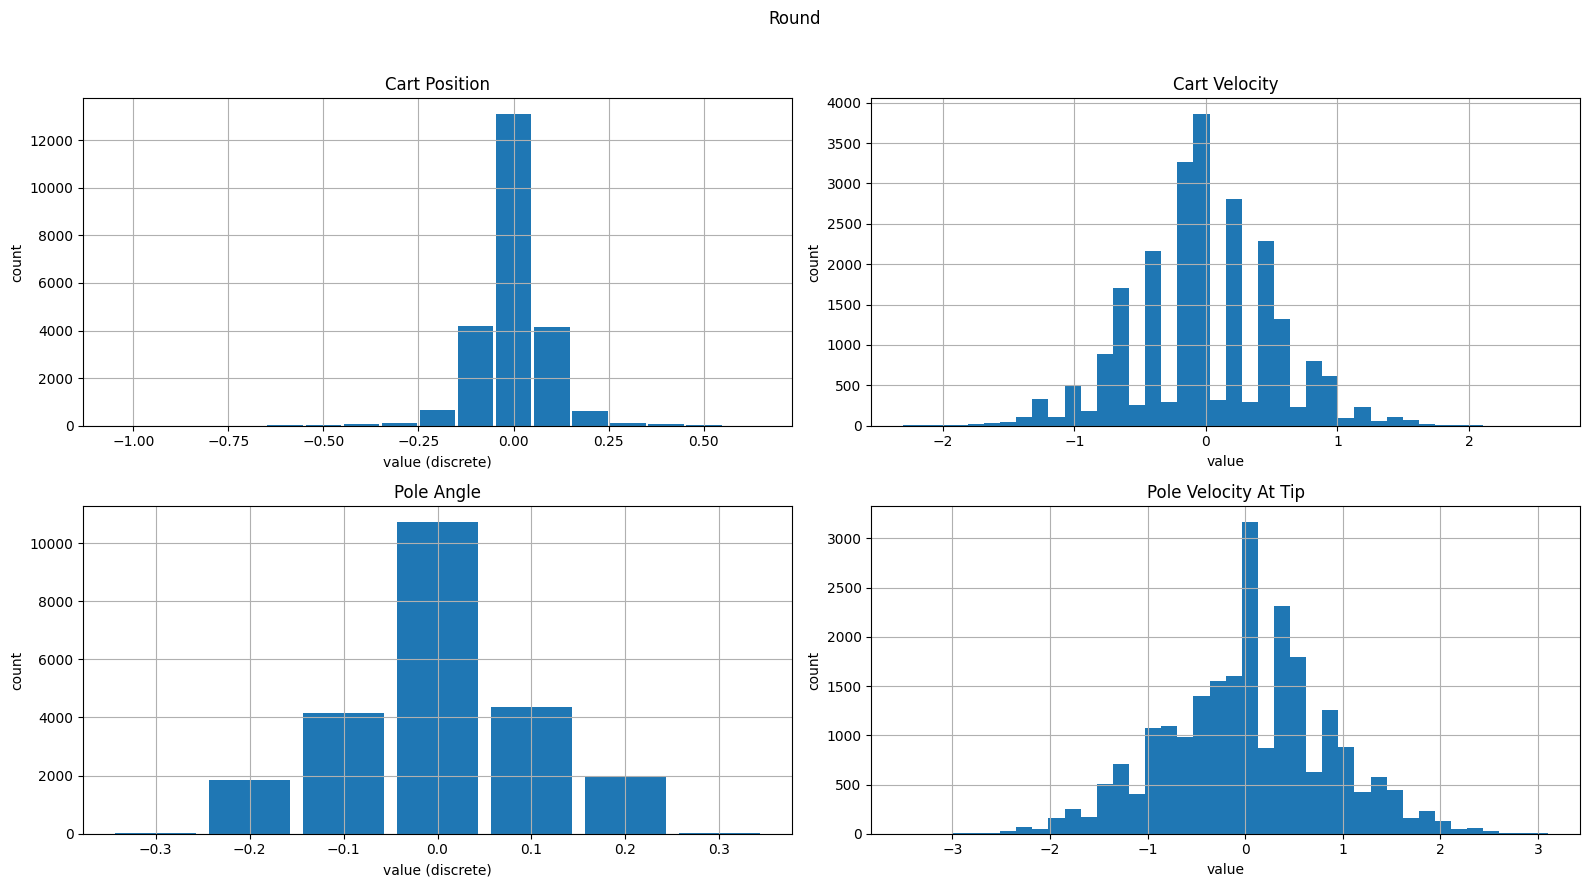

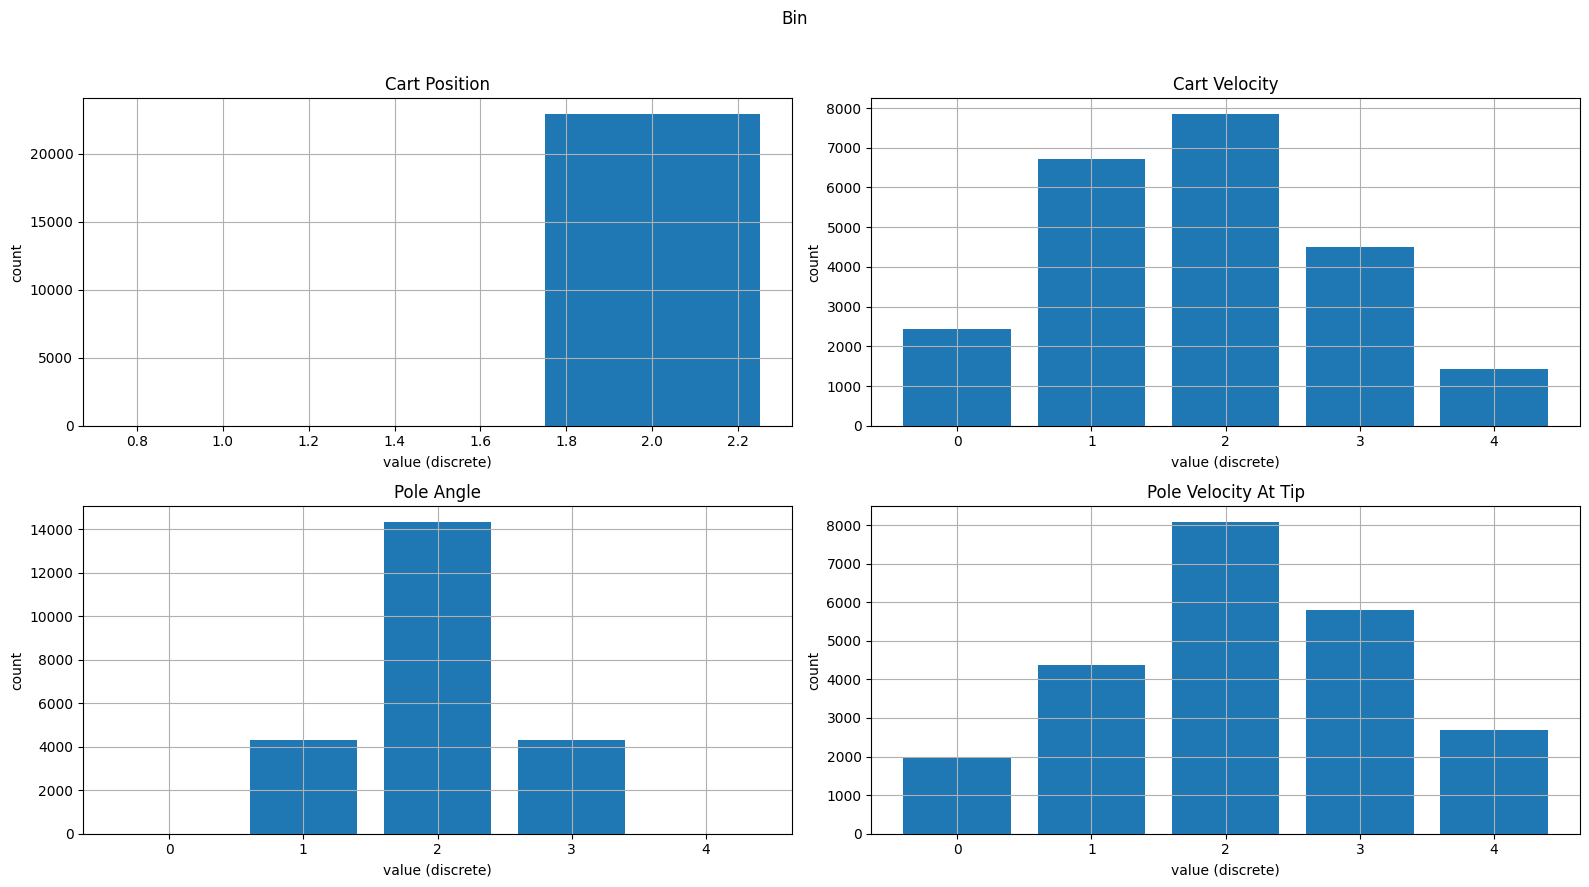

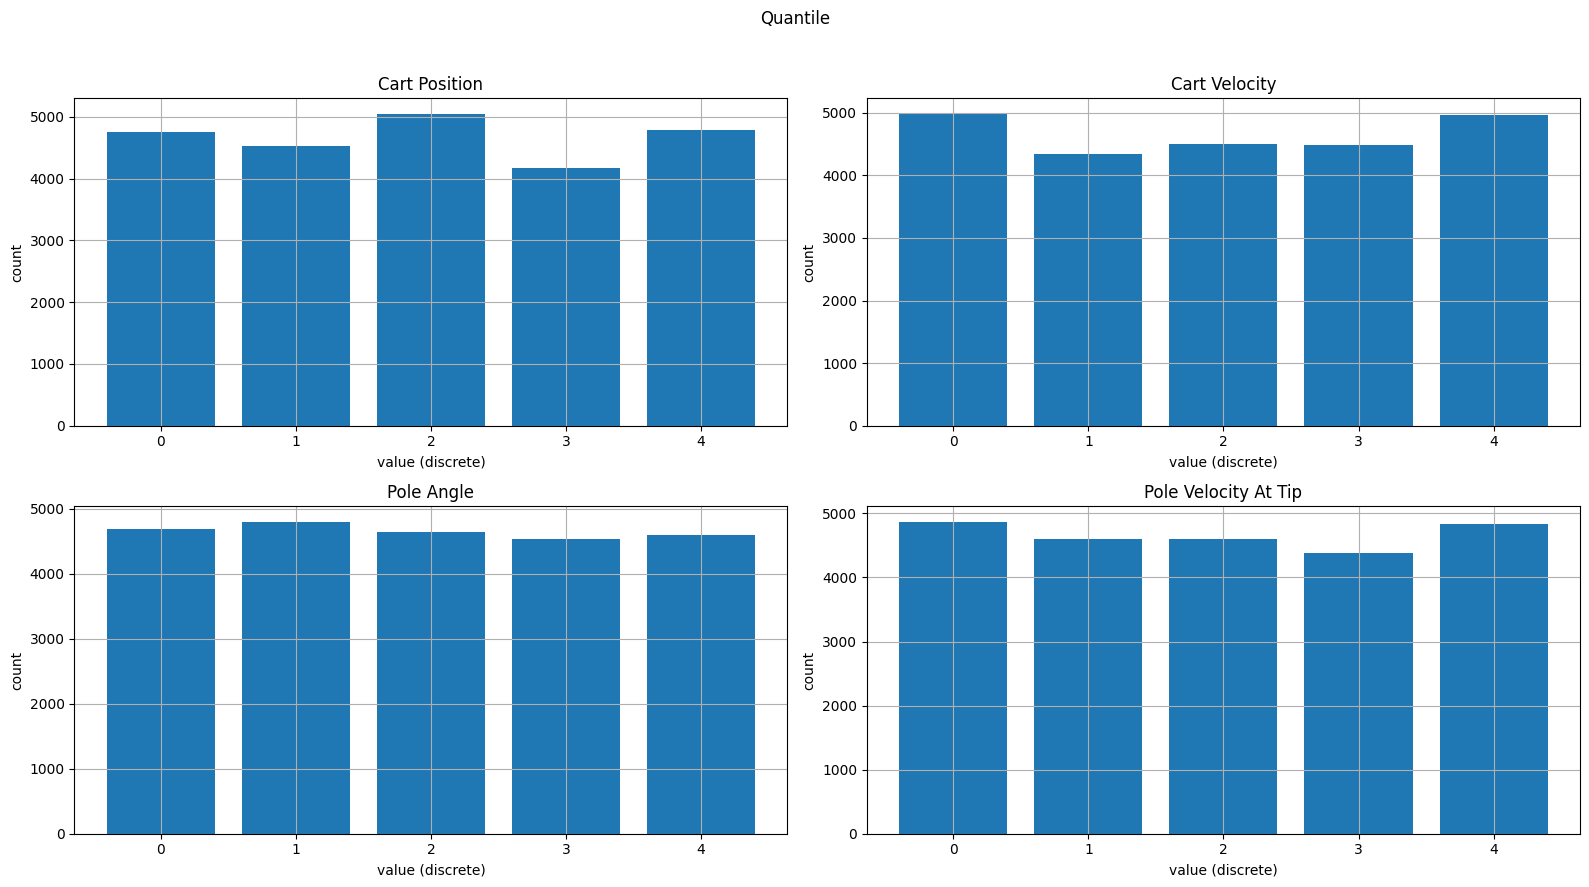

In [18]:
from gymnasium import make

env = make("CartPole-v1", render_mode=None)

ndigits = [1,1,1,1]
n_bins = 5

discretizers = {
    "Round": lambda e: RoundDiscretizer(e, ndigits=ndigits),
    "Bin": lambda e: BinDiscretizer(e, n_bins=n_bins),
    "Quantile": lambda e: QuantileDiscretizer(e, n_bins=n_bins, sample_size=3000)
}

for name, factory in discretizers.items():
    env_d = factory(make_env())
    seen_observations = []
    for _ in range(1000):
        s, _ = env_d.reset()
        seen_observations.append(s)
        done = False
        while not done:
            s, r, done, _, _ = env_d.step(env_d.action_space.sample())
            seen_observations.append(s)
    visualize_cartpole_observation_distribution(seen_observations, title=name)


In [19]:
import numpy as np
from collections import Counter
from typing import Tuple, Dict, Any

# --------------- Empirical: сколько уникальных состояний реально встречается ---------------
def empirical_state_count(env, n_steps: int = 5000) -> Dict[str, Any]:
    """
    env -- уже обёрнутый env (т.е. возвращает дискретное наблюдение при reset/step)
    n_steps -- сколько шагов соберём (не эпизодов). Возвращаем:
      - 'unique_states' : set of states (tuples)
      - 'count' : len(unique_states)
      - 'per_dim_unique' : list of unique counts per dimension (if states are tuples/arrays)
      - 'sampled' : number of collected samples
    """
    seen = []
    obs, _ = env.reset()
    seen.append(obs)
    steps = 1
    while steps < n_steps:
        a = env.action_space.sample()
        obs, _, done, _, _ = env.step(a)
        seen.append(obs)
        steps += 1
        if done:
            obs, _ = env.reset()
            seen.append(obs)
            steps += 1
    # normalize to tuples (hashable)
    def to_tuple(x):
        if isinstance(x, tuple):
            return x
        x = np.asarray(x)
        # convert floats to python floats or ints
        return tuple((float(v) if np.issubdtype(type(v), np.floating) or isinstance(v, float) else int(v)) for v in x)

    tuples = [to_tuple(s) for s in seen]
    unique_states = set(tuples)
    # per-dim unique
    arr = np.array(list(tuples))
    per_dim_unique = [len(np.unique(arr[:, i])) for i in range(arr.shape[1])]
    return {
        "sampled": len(tuples),
        "count": len(unique_states),
        "unique_states": unique_states,
        "per_dim_unique": per_dim_unique,
        "example_states": list(unique_states)[:10]
    }

# --------------- Theoretical: попытка вывести макс.число состояний из дискретизатора ---------------
def theoretical_state_count_from_discretizer(disc) -> Tuple[int, Dict]:
    """
    Попытаться вычислить верхнюю границу числа дискретных состояний по атрибутам дискретизатора.
    Возвращает (theoretical_count, details_per_dim)
    Поддерживаем: BinDiscretizer (n_bins), QuantileDiscretizer (n_bins), RoundDiscretizer (ndigits with known bounds).
    Если невозможно вычислить, возвращаем -1.
    """
    # 1) QuantileDiscretizer: edges -> n_bins per dim
    if hasattr(disc, "edges"):
        # edges list of arrays, len(edges)=dims, each edges length = n_bins+1
        dims = len(disc.edges)
        per_dim = []
        for e in disc.edges:
            # number of bins = unique intervals = len(e)-1, but ensure >0
            per_dim.append(max(1, len(np.unique(e)) - 1))
        product = int(np.prod(per_dim))
        return product, {"per_dim": per_dim, "type": "quantile/edges"}

    # 2) BinDiscretizer: n_bins attribute
    if hasattr(disc, "n_bins"):
        # if n_bins is scalar -> same for all dims
        try:
            n = int(disc.n_bins)
            # number of dims: try to infer from low/high or from observation_space
            if hasattr(disc, "low"):
                dims = len(disc.low)
            elif hasattr(disc, "observation_space"):
                dims = int(np.prod(disc.observation_space.shape))
            else:
                dims = None
            if dims is not None:
                per_dim = [n] * dims
                return int(n**dims), {"per_dim": per_dim, "type": "bin_n_bins_scalar"}
        except Exception:
            pass

    # 3) RoundDiscretizer: if ndigits and env bounds known we can approximate
    if hasattr(disc, "ndigits"):
        nd = tuple(disc.ndigits)
        # try to get bounds from wrapped env if available
        bounds = None
        if hasattr(disc, "observation_space"):
            try:
                low = np.array(disc.observation_space.low, dtype=float)
                high = np.array(disc.observation_space.high, dtype=float)
                # if finite bounds, compute approximate counts per dim
                if np.all(np.isfinite(low)) and np.all(np.isfinite(high)):
                    per_dim = []
                    for i, d in enumerate(nd):
                        step = 10 ** (-d)
                        nvals = int(np.floor((high[i] - low[i]) / step)) + 1
                        nvals = max(1, nvals)
                        per_dim.append(nvals)
                    product = int(np.prod(per_dim))
                    return product, {"per_dim": per_dim, "type": "round_from_bounds"}
            except Exception:
                pass
    # fallback: нельзя вычислить
    return -1, {"reason": "cannot infer theoretical count from given discretizer"}

# --------------- Example usage ---------------
# env_d = RoundDiscretizer(make_env(), ndigits=(1,1,2,2))  # or BinDiscretizer, QuantileDiscretizer
# result = empirical_state_count(env_d, n_steps=5000)
# print("Empirical unique states:", result["count"])
# print("Per-dim unique:", result["per_dim_unique"])
# print("Example states:", result["example_states"])
# theo, details = theoretical_state_count_from_discretizer(env_d)
# print("Theoretical (upper bound) states:", theo, details)


## Test state dimensions

In [20]:
# approx. 1.3k, s_sample = [18, 44, 7, 57]
# env_d = RoundDiscretizer(make_env(), ndigits=(1,1,1,1)) 

# approx. 285, s_sample = [n_bins] * 4
#env_d = QuantileDiscretizer(make_env(), n_bins=5, sample_size=3000)

# approx. 45, s_sample = [1], [5] * 3
# NOTE 1st bin is broken, first dim seems to be too small
# env_d = BinDiscretizer(make_env(), n_bins=5)

env_d = RoundDiscretizer(make_env(), ndigits=(1,1,3,3)) 

result = empirical_state_count(env_d, n_steps=5000)
print("Empirical unique states:", result["count"])
print("Per-dim unique:", result["per_dim_unique"])
print("Example states:", result["example_states"])
theo, details = theoretical_state_count_from_discretizer(env_d)
print("Theoretical (upper bound) states:", theo, details)

Empirical unique states: 4983
Per-dim unique: [13, 38, 487, 2477]
Example states: [(0.1, -0.0, -0.149, -0.358), (0.1, 1.4, -0.135, -2.11), (-0.0, 0.4, -0.003, -0.476), (0.0, 0.4, -0.096, -0.735), (-0.0, -0.4, 0.097, 0.77), (-0.0, -0.2, -0.016, 0.318), (-0.0, 0.4, 0.024, -0.488), (-0.0, 0.6, 0.03, -0.835), (0.0, -0.4, -0.03, 0.565), (0.0, -0.0, -0.003, -0.048)]
Theoretical (upper bound) states: -1 {'reason': 'cannot infer theoretical count from given discretizer'}


## Learn discretized policy

Now let's train a policy that uses discretized state space.

__Tips:__

* Note that increasing the number of digits for one dimension of the observations increases your state space by a factor of $10$.
* If your discretization is too fine-grained, your agent will take much longer than 10000 steps to converge. You can either increase the number of iterations and reduce softmax temperature decay or change discretization. In practice we found that this kind of mistake is rather frequent.
* If your discretization is too coarse, your agent may fail to find the optimal policy. In practice we found that on this particular environment this kind of mistake is rare.
* **Start with a coarse discretization** and make it more fine-grained if that seems necessary.
* Having $10^3$–$10^4$ distinct states is recommended (`len(agent._qvalues)`), but not required.
* If things don't work without annealing $\varepsilon$, consider adding that, but make sure that it doesn't go to zero too quickly.

A reasonable agent should attain an average reward of at least 50.

__My notes__:

- Rule-of-thumb complexity: you need something roughly proportional to 
∣𝑆∣×∣𝐴∣ effective visits (order-wise) to fill the table well. So doubling levels can double/quadruple required interactions.
- Try adapt temperature
- 

In [21]:
import pandas as pd


def moving_average(x, span=100):
    return pd.DataFrame({"x": np.asarray(x)}).x.ewm(span=span).mean().values

In [22]:
# rewards = []
# env = make_env()
# env = QuantileDiscretizer(env, n_bins=5, sample_size=3000)

# agent = QLearningAgent(alpha=0.9, 
#                        discount=0.99, 
#                        get_legal_actions=lambda s: range(n_actions),
#                        temp=0.2)

# moving_average(rewards)
# temp = 1.0
# temp_inc_rate = 1.2
# temp_dec_rate = 0.8


In [29]:
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np

def run_experiment(env, agent, n_steps, ewma_window, name="Experiment"):
    rewards = []
    rewards_ewma = []
    temp = agent.temp

    display(f"Starting {name}...")

    fig, ax = plt.subplots(figsize=(12,5))
    display(fig)  # покажем фигуру заранее

    for i in range(n_steps):
        agent.decay_eps()

        reward = play_and_train(env, agent)
        rewards.append(reward)

        if i % ewma_window == 0 and i > 0:
            rewards_ewma = moving_average(rewards, span=ewma_window)

            clear_output(wait=True)   
            ax.clear()
            ax.plot(rewards, alpha=0.3, label="rewards", color='blue')
            x_ewma = np.arange(len(rewards_ewma)) + (len(rewards) - len(rewards_ewma))
            ax.plot(x_ewma, rewards_ewma, label=f"rewards ewma@{ewma_window}", color='red', linewidth=2)
            ax.legend()
            ax.grid()
            ax.set_title(f"{name} Progress (Step {i})")
            display(fig)

    display(f"\n{name} finished.")
    display(f"Learned {len(agent._qvalues)} Q-values.")
    display(f"Mean reward: {np.mean(rewards):.3f}\n")

    return rewards, rewards_ewma


def run_multiple_experiments(exp_configs):
    all_results = {}
    for name, (env, agent, params) in exp_configs.items():
        print(f"Running experiment: {name}")
        rewards, rewards_ewma = run_experiment(
            env,
            agent,
            n_steps=params.get("n_steps", 500),
            ewma_window=params.get("ewma_window", 100)            
        )
        all_results[name] = (rewards, rewards_ewma)
    return all_results

def plot_summary(all_results):
    plt.figure(figsize=(12,6))
    for name, (rewards, rewards_ewma) in all_results.items():
        if len(rewards_ewma) > 0:
            x_ewma = np.arange(len(rewards_ewma)) + (len(rewards) - len(rewards_ewma))
            plt.plot(x_ewma, rewards_ewma, label=name, linewidth=2)
    plt.xlabel("Step")
    plt.ylabel("Reward")
    plt.title("Comparison of Experiments (EWMA)")
    plt.grid()
    plt.legend()
    plt.show()



In [30]:
aggressive_agent_args = {
    "alpha": 1.2,        # learning rate высокий — быстрее меняет Q
    "discount": 0.99,    
    "temp": 2.0,          # softmax более “жадный” к высоким Q
    "eps_start": 1.0,     # исследует почти всё в начале
    "eps_end": 0.05,      # к концу почти полностью greedy
    "n_steps": 2500
}

calm_agent_args = {
    "alpha": 0.7,        # медленный learning rate — аккуратно обновляет Q
    "discount": 0.99,
    "temp": 1.0,         # softmax мягче — менее резкие скачки
    "eps_start": 0.5,    # начинает умеренно исследовать
    "eps_end": 0.05,     # к концу greedy
    "n_steps": 2500
}


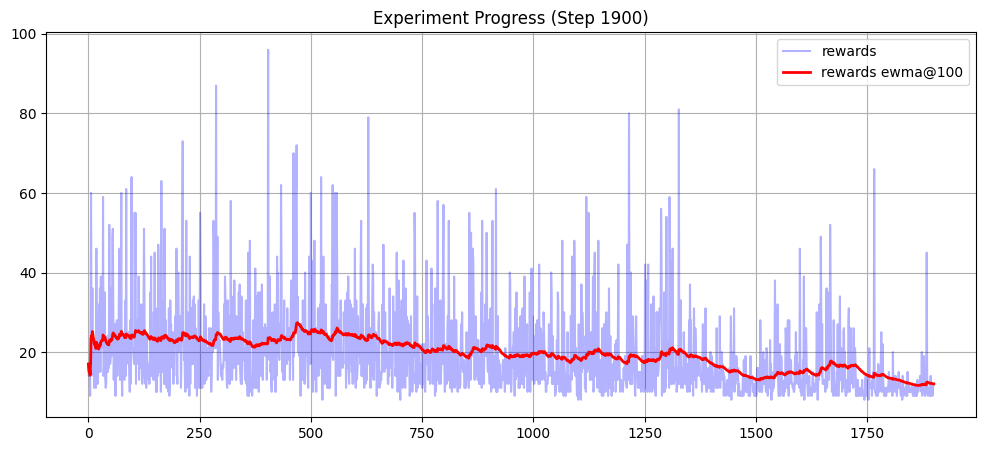

'\nExperiment finished.'

'Learned 2787 Q-values.'

'Mean reward: 19.160\n'

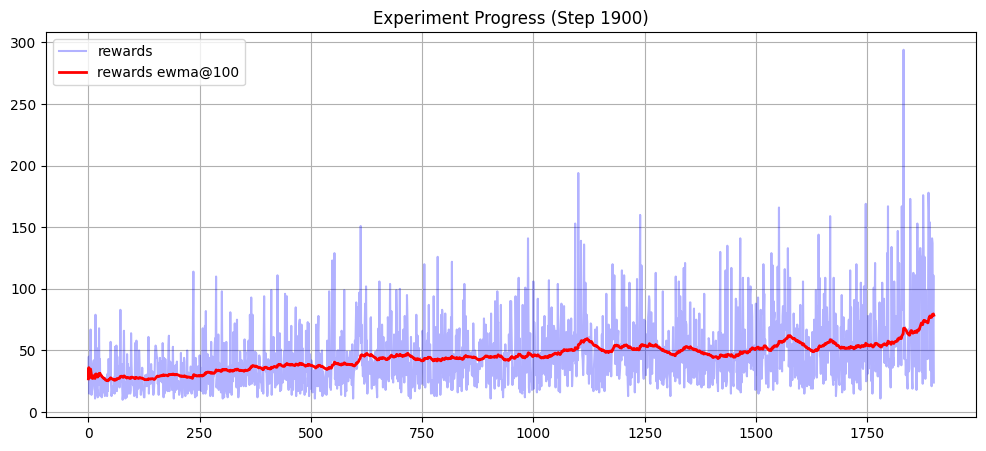

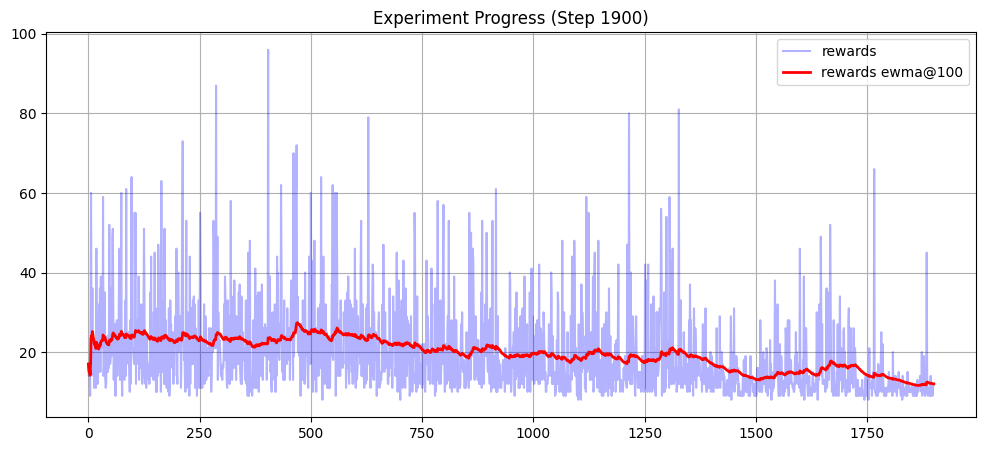

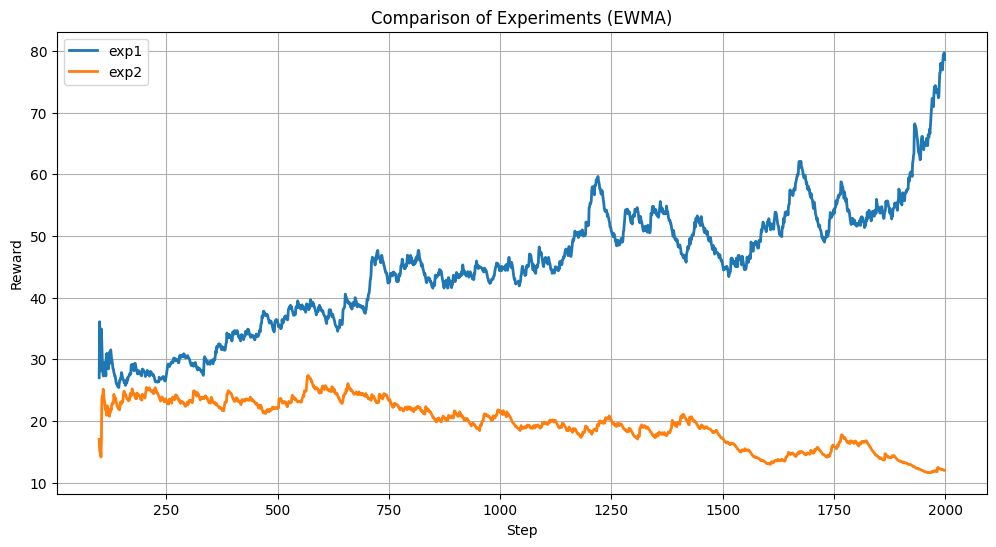

In [33]:
def updated(d, **kwargs):
    new_d = d.copy()
    new_d.update(kwargs)
    return new_d


def make_agent(alpha, discount, temp, eps_start, eps_end, n_steps):
    return QLearningAgent(
        alpha=alpha,
        discount=discount,
        get_legal_actions=lambda s: range(n_actions),
        temp=temp,
        eps_start=eps_start,
        eps_end=eps_end,
        n_steps=n_steps
    )

def make_quantile_env(n_bins, sample_size):
    env = make_env()
    return QuantileDiscretizer(env, n_bins=n_bins, sample_size=sample_size)

def make_round_env(ndigits):
    env = make_env()
    return RoundDiscretizer(env, ndigits=ndigits)


params = {
    "n_steps": 2000, 
    "ewma_window": 100
}

quantile_env_args = {"n_bins":5, "sample_size":5000}

round_env_args = {"ndigits":(1,1,1,1)} 

agent_args = {"alpha":0.9, "discount":0.99, "temp":1.0, "eps_start":1.0, "eps_end":0.05, "n_steps": params["n_steps"]}

exp_configs = {
    "exp1": (
        make_round_env(**round_env_args),
        make_agent(**calm_agent_args),
        params
    ),
    "exp2": (
        make_round_env(**updated(round_env_args)),
        make_agent(**aggressive_agent_args),
        params
    )
}

results = run_multiple_experiments(exp_configs)
plot_summary(results)


## Step 3: EV-SARSA with softmax policy

The policy we're going to use is still softmax, but now the state  value is computed differently.

We inherit from the existing implementation of `QLearningAgent` and only update the `get_value` method.

In [34]:
class EVSarsaAgent(QLearningAgent):
    """
    An agent that changes some of q-learning functions to implement Expected Value SARSA.
    Note: this demo assumes that your implementation of QLearningAgent.update uses get_value(next_state).
    If it doesn't, please add
        def update(self, state, action, reward, next_state):
            and implement it for Expected Value SARSA's V(s')
    """

    def get_value(self, state):
        """
        Returns Vpi for current state under the softmax policy:
          V_{pi}(s) = sum _{over a_i} {pi(a_i | s) * Q(s, a_i)}

        Hint: all other methods from QLearningAgent are still accessible.
        """
        possible_actions = self.get_legal_actions(state)

        if len(possible_actions) == 0:
            return 0.0

        qvalues = [self.get_qvalue(state=state, action=a) for a in possible_actions]

        probabilities = self.get_softmax_policy(state=state) 

        value = np.sum(probabilities * qvalues) 

        return value


### Cliff World

Let's now see how our algorithm compares against q-learning in case where we force agent to explore all the time.

<img src=https://github.com/yandexdataschool/Practical_RL/raw/master/yet_another_week/_resource/cliffworld.png width=600>
<center><i>Image from CS188</i></center>

In [46]:
env = gym.make("CliffWalking-v1", render_mode="rgb_array")
n_actions = env.action_space.n

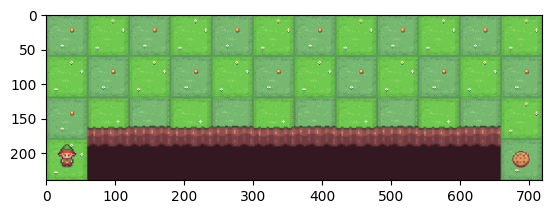

In [47]:
# Our cliffworld has one difference from what's in the image: there is no wall.
# Agent can choose to go as close to the cliff as it wishes.
# x:start, T:exit, C:cliff, o: flat ground

env.reset()
plt.imshow(env.render())

In [48]:
agent_sarsa = EVSarsaAgent(alpha=0.25, discount=0.99, get_legal_actions=lambda s: range(n_actions))

agent_ql = QLearningAgent(alpha=0.25, discount=0.99, get_legal_actions=lambda s: range(n_actions))

EVSARSA mean reward = -18.38
QLEARNING mean reward = -24.51


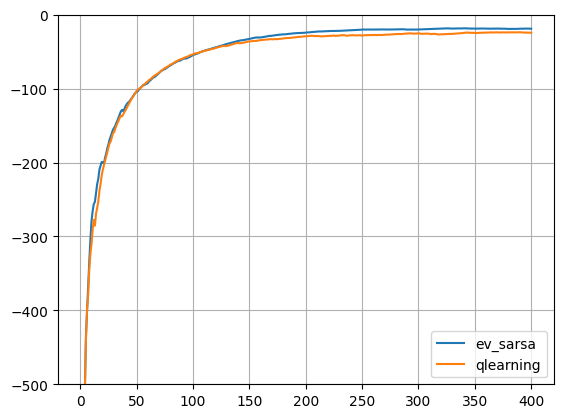

In [45]:
from IPython.display import clear_output


def moving_average(x, span=100):
    return pd.DataFrame({"x": np.asarray(x)}).x.ewm(span=span).mean().values


rewards_sarsa, rewards_ql = [], []

for i in range(500):
    rewards_sarsa.append(play_and_train(env, agent_sarsa))
    rewards_ql.append(play_and_train(env, agent_ql))

    if i % 100 == 0:
        clear_output(True)
        print("EVSARSA mean reward =", np.mean(rewards_sarsa[-100:]))
        print("QLEARNING mean reward =", np.mean(rewards_ql[-100:]))
        plt.plot(moving_average(rewards_sarsa), label="ev_sarsa")
        plt.plot(moving_average(rewards_ql), label="qlearning")
        plt.grid()
        plt.legend()
        plt.ylim(-500, 0)
        plt.show()

Let's now see what did the algorithms learn by visualizing their actions at every state.

In [49]:
def draw_policy(agent):
    """Prints CliffWalkingEnv policy with arrows. Hard-coded."""

    env = gym.make("CliffWalking-v1", render_mode="ansi")
    env.reset()
    grid = [x.split("  ") for x in env.render().split("\n")[:4]]

    n_rows, n_cols = 4, 12
    start_state_index = 36
    actions = "^>v<"

    for yi in range(n_rows):
        for xi in range(n_cols):
            if grid[yi][xi] == "C":
                print(" C ", end="")
            elif (yi * n_cols + xi) == start_state_index:
                print(" X ", end="")
            elif (yi * n_cols + xi) == n_rows * n_cols - 1:
                print(" T ", end="")
            else:
                print(" %s " % actions[agent.get_best_action(yi * n_cols + xi)], end="")
        print()

In [50]:
print("Q-Learning")
draw_policy(agent_ql)

print("SARSA")
draw_policy(agent_sarsa)

Q-Learning
 ^  ^  ^  ^  ^  ^  ^  ^  ^  ^  ^  ^ 
 ^  ^  ^  ^  ^  ^  ^  ^  ^  ^  ^  ^ 
 ^  ^  ^  ^  ^  ^  ^  ^  ^  ^  ^  ^ 
 X  C  C  C  C  C  C  C  C  C  C  T 
SARSA
 ^  ^  ^  ^  ^  ^  ^  ^  ^  ^  ^  ^ 
 ^  ^  ^  ^  ^  ^  ^  ^  ^  ^  ^  ^ 
 ^  ^  ^  ^  ^  ^  ^  ^  ^  ^  ^  ^ 
 X  C  C  C  C  C  C  C  C  C  C  T 


Congratulations! Finally, copy the `QLearningAgent`, `EVSarsaAgent` and `my_softmax` to the template and submit them to the Contest.

Good luck!